In [1]:
!pip install "numpy==2.0.2" pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 57.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 55.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 66.5 MB/s eta 0:00:00:00:010:01m


In [2]:
"""
evaluation_schemes.py

"""

import numpy as np
from sklearn.metrics import f1_score, hamming_loss, classification_report



def exact_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape, "gold and preds must have the same shape"

    # Row-wise equality: True only when ALL labels in a row match
    row_matches = np.all(gold == preds, axis=1)          # (N,) bool
    emr = float(row_matches.mean())                      # Exact Match Ratio

    # For a strict binary decision (match vs. no-match):
    #   TP = matched samples, FP = 0, FN = 0  →  P = R = F1 = EMR
    return {
        "precision"         : emr,
        "recall"            : emr,
        "f1"                : emr,
        "exact_match_ratio" : emr,
        "num_exact_matches" : int(row_matches.sum()),
    }



def _instance_prf(gold_row: np.ndarray, pred_row: np.ndarray):
    
    gold_set = set(np.where(gold_row == 1)[0])
    pred_set = set(np.where(pred_row == 1)[0])

    # Both empty → perfect prediction
    if len(gold_set) == 0 and len(pred_set) == 0:
        return 1.0, 1.0, 1.0

    # One empty, the other not → zero overlap
    if len(gold_set) == 0 or len(pred_set) == 0:
        return 0.0, 0.0, 0.0

    overlap = len(gold_set & pred_set)
    precision = overlap / len(pred_set)
    recall    = overlap / len(gold_set)
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


def partial_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape

    precisions, recalls, f1s = [], [], []
    for g_row, p_row in zip(gold, preds):
        p, r, f = _instance_prf(g_row, p_row)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    return {
        "precision" : float(np.mean(precisions)),
        "recall"    : float(np.mean(recalls)),
        "f1"        : float(np.mean(f1s)),
    }

def evaluate_all_schemes(
    gold: np.ndarray,
    preds: np.ndarray,
    label_names: list[str] | None = None,
    verbose: bool = True,
) -> dict:
    

    # ── Scheme 1 : Per-label sklearn metrics ──────────────────────────────────
    scheme1 = {
        "macro_f1"    : f1_score(gold, preds, average="macro",    zero_division=0),
        "micro_f1"    : f1_score(gold, preds, average="micro",    zero_division=0),
        "weighted_f1" : f1_score(gold, preds, average="weighted", zero_division=0),
        "hamming_loss": hamming_loss(gold, preds),
    }

    # ── Scheme 2 : Exact match ────────────────────────────────────────────────
    scheme2 = exact_match_scores(gold, preds)

    # ── Scheme 3 : Partial match ──────────────────────────────────────────────
    scheme3 = partial_match_scores(gold, preds)

    results = {"scheme1": scheme1, "scheme2": scheme2, "scheme3": scheme3}

    if verbose:
        _print_report(results, gold, preds, label_names)

    return results


def _print_report(results, gold, preds, label_names):
    sep = "=" * 62

    print(sep)
    print("  SCHEME 1 – Per-label sklearn metrics  (existing baseline)")
    print(sep)
    s1 = results["scheme1"]
    print(f"  Macro  F1      : {s1['macro_f1']:.4f}")
    print(f"  Micro  F1      : {s1['micro_f1']:.4f}")
    print(f"  Weighted F1    : {s1['weighted_f1']:.4f}")
    print(f"  Hamming Loss   : {s1['hamming_loss']:.4f}")
    if label_names:
        print("\n  Per-label classification report:")
        print(
            classification_report(
                gold, preds,
                target_names=label_names,
                digits=4,
                zero_division=0,
            )
        )

    print(sep)
    print("  SCHEME 2 – Exact Match")
    print(sep)
    s2 = results["scheme2"]
    print(f"  Exact Match Ratio (EMR) : {s2['exact_match_ratio']:.4f}")
    print(f"  Num Exact Matches       : {s2['num_exact_matches']}")
    print(f"  Precision               : {s2['precision']:.4f}")
    print(f"  Recall                  : {s2['recall']:.4f}")
    print(f"  F1                      : {s2['f1']:.4f}")
    print("  [Note: P = R = F1 = EMR for strict exact-match scoring]")

    print(sep)
    print("  SCHEME 3 – Partial Match  (instance-level set overlap)")
    print(sep)
    s3 = results["scheme3"]
    print(f"  Precision (macro-inst.) : {s3['precision']:.4f}")
    print(f"  Recall    (macro-inst.) : {s3['recall']:.4f}")
    print(f"  F1        (macro-inst.) : {s3['f1']:.4f}")
    print(sep)



if __name__ == "__main__":
    rng = np.random.default_rng(42)

    EMOTION_COLS = ["Love", "Joy", "Surprise", "Anger", "Sadness", "Fear"]

    # Simulate gold labels and predictions
    gold  = (rng.random((50, 6)) > 0.6).astype(int)
    preds = gold.copy()

    # Flip ~15 % of bits to simulate imperfect predictions
    flip_mask = rng.random((50, 6)) < 0.15
    preds[flip_mask] = 1 - preds[flip_mask]

    # --- Manual examples from the task description ---
    print("Manual example checks")
    print("-" * 40)

    g1 = np.array([[0, 0, 1, 1, 0, 1]])
    p1 = np.array([[0, 0, 1, 1, 0, 1]])   # perfect
    g2 = np.array([[0, 0, 1, 1, 0, 1]])
    p2 = np.array([[0, 0, 1, 1, 0, 0]])   # one label off

    print("Example 1 (perfect):")
    print(f"  Exact match score  : {exact_match_scores(g1, p1)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g1, p1)['f1']:.4f}")

    print("Example 2 (one label off):")
    print(f"  Exact match score  : {exact_match_scores(g2, p2)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g2, p2)['f1']:.4f}")

    print("\nFull 50-sample evaluation:")
    evaluate_all_schemes(gold, preds, label_names=EMOTION_COLS, verbose=True)

Manual example checks
----------------------------------------
Example 1 (perfect):
  Exact match score  : 1.0
  Partial match F1   : 1.0000
Example 2 (one label off):
  Exact match score  : 0.0
  Partial match F1   : 0.8000

Full 50-sample evaluation:
  SCHEME 1 – Per-label sklearn metrics  (existing baseline)
  Macro  F1      : 0.8069
  Micro  F1      : 0.8097
  Weighted F1    : 0.8147
  Hamming Loss   : 0.1567

  Per-label classification report:
              precision    recall  f1-score   support

        Love     0.7826    0.8182    0.8000        22
         Joy     0.7727    0.8500    0.8095        20
    Surprise     0.5714    0.8571    0.6857        14
       Anger     0.8095    0.9444    0.8718        18
     Sadness     0.6667    0.8421    0.7442        19
        Fear     0.9524    0.9091    0.9302        22

   micro avg     0.7576    0.8696    0.8097       115
   macro avg     0.7592    0.8702    0.8069       115
weighted avg     0.7727    0.8696    0.8147       115
 samp

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, hamming_loss
)
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm
import pennylane as qml

try:
    from evaluation_schemes import evaluate_all_schemes
except ModuleNotFoundError:
    pass  # already defined by the pasted code cell above

In [4]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

GPU device: cuda
CPU device: cpu


In [5]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across PyTorch, NumPy, and Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [6]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

/kaggle/input/datasets/sayanmanik2005/kaggle/Val.csv
/kaggle/input/datasets/sayanmanik2005/kaggle/Train.csv
/kaggle/input/datasets/sayanmanik2005/kaggle/Test.csv


In [7]:
import glob
csv_files = glob.glob('/kaggle/input/**/Train.csv', recursive=True)
print('Found:', csv_files)
assert len(csv_files) >= 1, 'No Train.csv found under /kaggle/input'
base = csv_files[0].rsplit('/', 1)[0]

df_tr = pd.read_csv(f'{base}/Train.csv')
df_vl = pd.read_csv(f'{base}/Val.csv')
df_te = pd.read_csv(f'{base}/Test.csv')
# Reset indices for safe iloc access in Dataset
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print("Train:", df_tr.shape, "| Valid:", df_vl.shape, "| Test:", df_te.shape)
df_tr.head()


Found: ['/kaggle/input/datasets/sayanmanik2005/kaggle/Train.csv']
Train: (18420, 11) | Valid: (2047, 11) | Test: (2272, 11)


,ID,Data,Love,Joy,Surprise,Anger,Sadness,Fear,Topic,Domain,is_admin
0,5454,লকাল বাস ভালো এটা থেকে,0,0,0,0,1,0,Travel,Youtube,False
1,22549,কত অভিজানই তো চলে কিন্তু ওয়াসার পানির অভিজান ক...,0,0,0,0,1,0,Politics,Youtube,False
2,7033,বিয়ের মহল ছেড়ে তিনি বিস্রাম নিতে চলে যান (৬ ...,0,0,0,1,0,0,Personal,Facebook,False
3,21114,চাচাজি তো কেবল মাকে ধর্ষণ করেছেন,0,0,0,0,1,0,Education,Facebook,False
4,23683,সত্যিকার মানুষ তারাই ভাই,0,1,0,0,0,0,Personal,Youtube,False


In [8]:
EMOTION_COLS = ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']
TEXT_COL     = 'Data'
NUM_LABELS   = len(EMOTION_COLS)

for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    assert TEXT_COL in split_df.columns, f"{split_name}: missing column '{TEXT_COL}'"
    assert all(c in split_df.columns for c in EMOTION_COLS), \
        f"{split_name}: missing emotion columns"

print(f"NUM_LABELS = {NUM_LABELS}  →  {EMOTION_COLS}")
print("\nTrain label distribution:")
print(df_tr[EMOTION_COLS].sum().sort_values(ascending=False))

NUM_LABELS = 6  →  ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']

Train label distribution:
Joy         8314
Sadness     4569
Love        3786
Anger       3542
Surprise     848
Fear         279
dtype: int64


In [9]:
class EmoNoBaDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            str(row[TEXT_COL]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        label = torch.tensor(
            row[EMOTION_COLS].values.astype(np.float32),
            dtype=torch.float32
        )

        return (
            encoding['input_ids'].squeeze(0),       # (max_length,)
            encoding['attention_mask'].squeeze(0),  # (max_length,)
            label                                   # (NUM_LABELS,)
        )

In [10]:
TEXT_MODEL   = 'ai4bharat/IndicBERTv2-MLM-only'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Text encoder loaded on: cuda:0


0: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
1: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
2: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
3: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
4: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
5: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
6: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···
7: ──RX(0.00)──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.02) ···

0: ··· ──Rot(0.00,0.00,0.00)──DepolarizingChannel(0.02)─╭●──DepolarizingChannel(0.02)─── ···
1: ··· ──Rot(0.00,0.00,0.00)──DepolarizingChannel(0.02)─╰Z──DepolarizingChannel(0.02)─╭● ···
2: ··· ──Rot(0.00,0.00,0.00)──DepolarizingChannel(0.02)───────────────────────────────╰Z ···
3: ··· ──Rot(0.00,0.00,0.00)──DepolarizingChannel(0.02)─────────

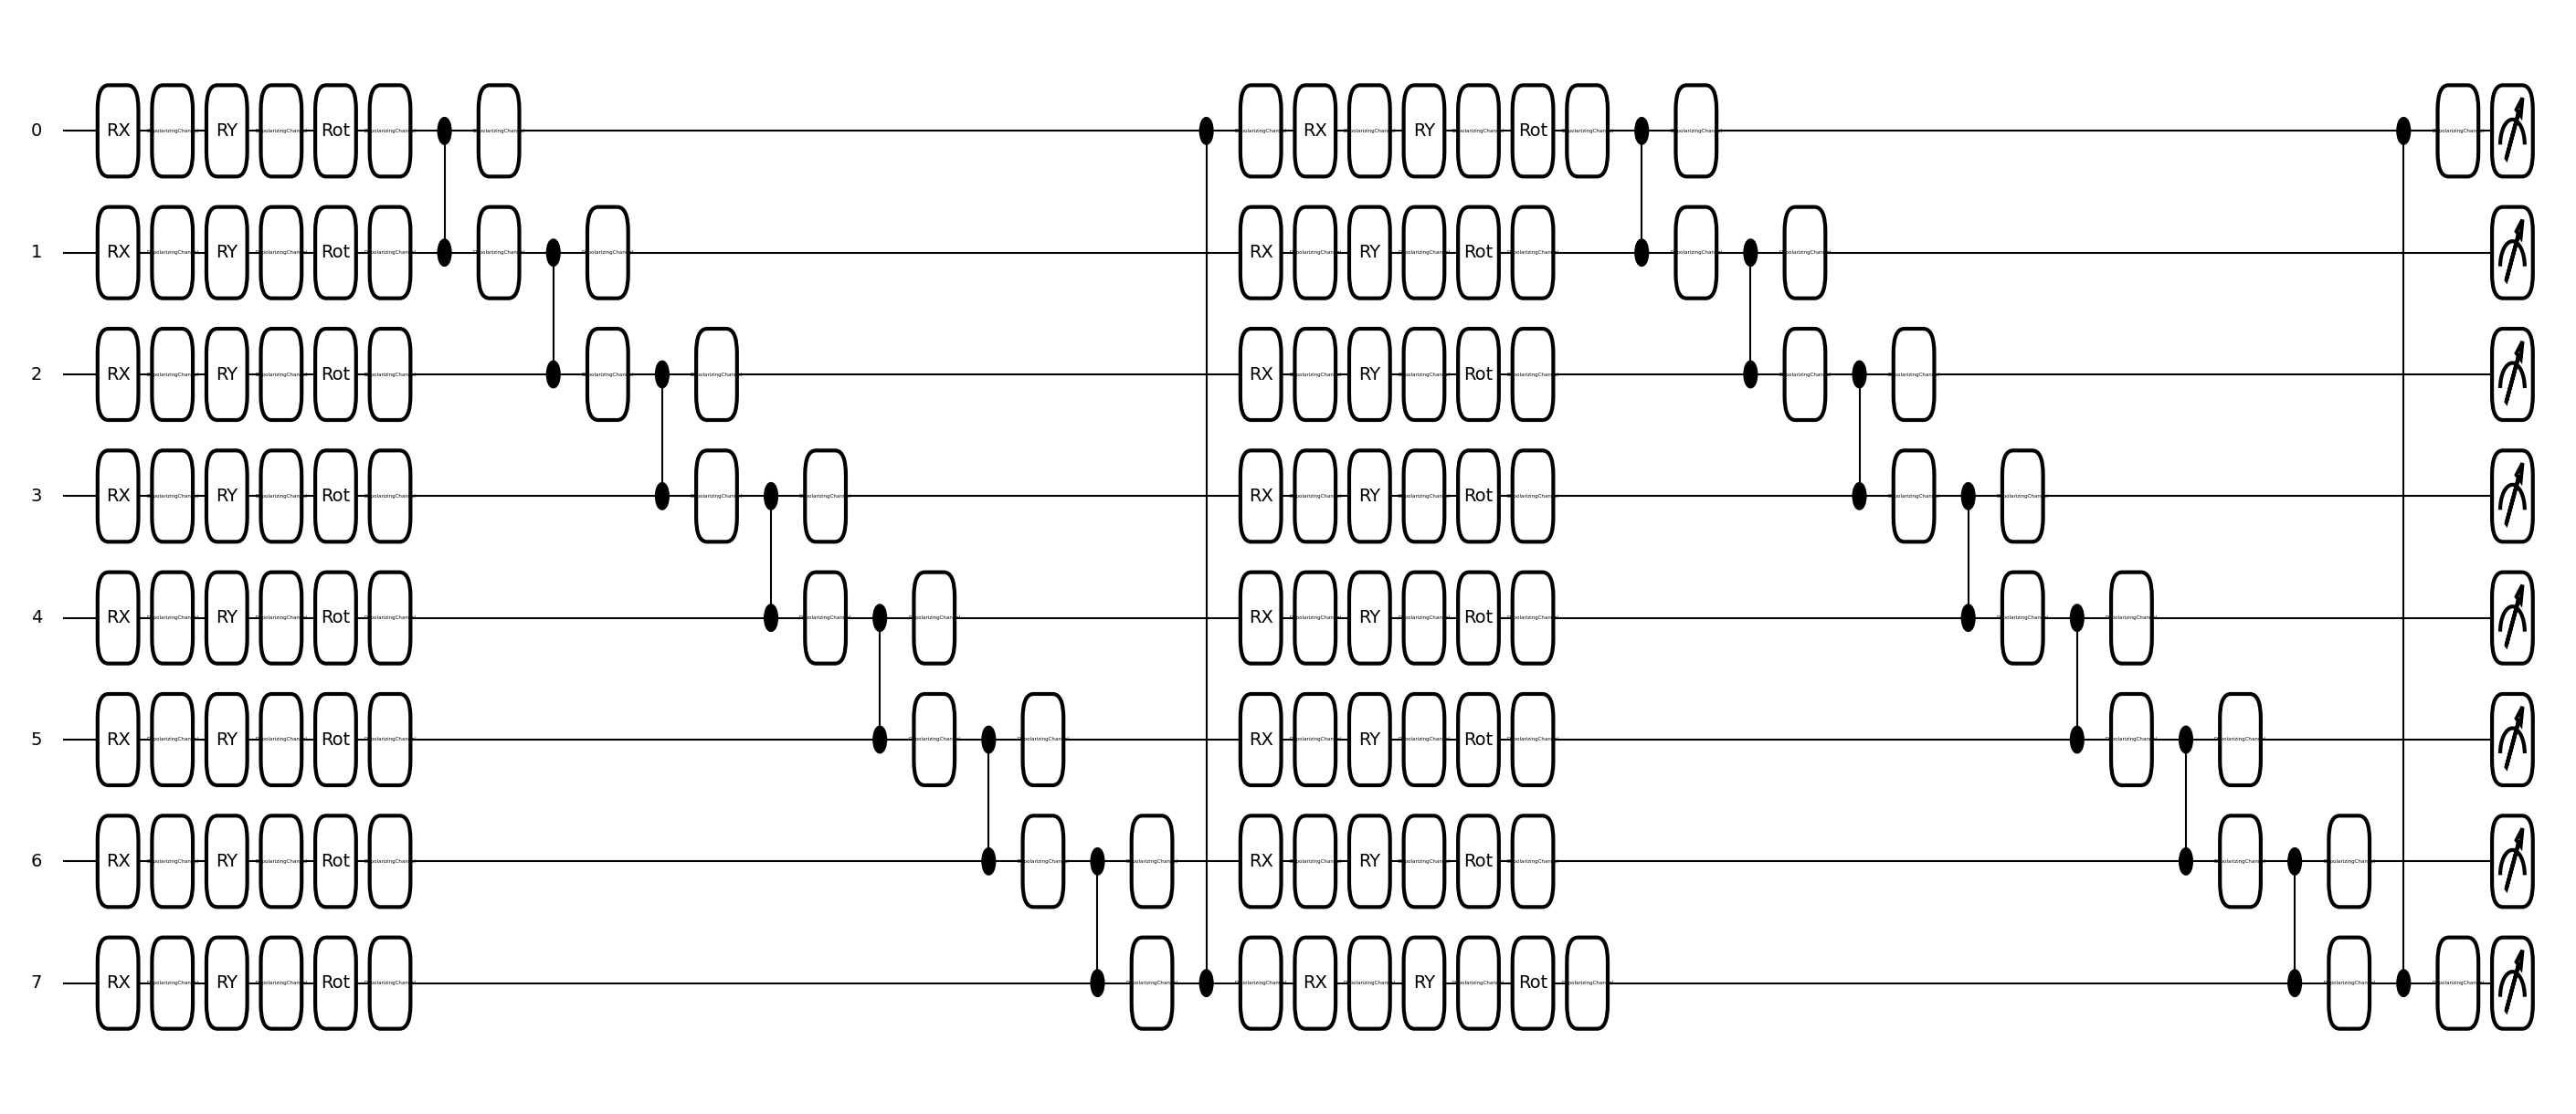

In [11]:
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt 

N_QUBITS   = 8
N_Q_LAYERS = 1

# REAL HARDWARE PROBABILITIES (IBM Quantum averages)
P_1Q = 0.02  # 2% error for single-qubit gates (RX, RY, Rot)
P_2Q = 0.02   # 2% error for two-qubit gates (CZ)

# Keep the boxes small in the drawing

dev = qml.device("default.mixed", wires=N_QUBITS)

class VQCParams(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_phi   = nn.Parameter(torch.zeros(N_QUBITS))
        self.input_scale = nn.Parameter(torch.full((N_QUBITS,), 0.5))
        self.weights     = nn.Parameter(torch.randn(N_Q_LAYERS, N_QUBITS, 3) * 0.1)

_vqc_params = VQCParams()

INPUT_PHI   = _vqc_params.input_phi
INPUT_SCALE = _vqc_params.input_scale
WEIGHTS     = _vqc_params.weights

def encode(inputs):
    """Put the 16-d input vector into 8 qubits (2 rotations per qubit) + Noise."""
    for q in range(N_QUBITS):
        c, s = torch.cos(INPUT_PHI[q]), torch.sin(INPUT_PHI[q])
        i0 = 2 * q
        i1 = 2 * q + 1
        x_rx = INPUT_SCALE[q] * (c * inputs[i0] - s * inputs[i1])
        x_ry = INPUT_SCALE[q] * (s * inputs[i0] + c * inputs[i1])
        
        qml.RX(x_rx, wires=q)
        qml.DepolarizingChannel(P_1Q, wires=q)  # Official PennyLane operation
        
        qml.RY(x_ry, wires=q)
        qml.DepolarizingChannel(P_1Q, wires=q)  # Official PennyLane operation
# 3. ANSATZ
def ansatz_block(w):
    """Trainable Rot on every qubit + a ring of CZ gates + Noise."""
    for q in range(N_QUBITS):
        qml.Rot(w[q, 0], w[q, 1], w[q, 2], wires=q)
        qml.DepolarizingChannel(P_1Q, wires=q)
        
    for q in range(N_QUBITS):
        ctrl = q
        targ = (q + 1) % N_QUBITS
        qml.CZ(wires=[ctrl, targ])
        
        qml.DepolarizingChannel(P_2Q, wires=ctrl)
        qml.DepolarizingChannel(P_2Q, wires=targ)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # encode -> ansatz -> re-encode -> ansatz
    encode(inputs)
    ansatz_block(weights)
    encode(inputs)
    ansatz_block(weights)
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)] + [qml.expval(qml.PauliX(q)) for q in range(N_QUBITS)]


# --- CIRCUIT PREVIEW ---
dummy_inputs  = torch.zeros(2 * N_QUBITS)
dummy_weights = torch.zeros(N_Q_LAYERS, N_QUBITS, 3).squeeze(0)

# Text-based preview
print(qml.draw(quantum_circuit)(dummy_inputs, dummy_weights))

# Matplotlib preview
fig, ax = qml.draw_mpl(quantum_circuit)(dummy_inputs, dummy_weights)
fig.set_size_inches(28, 12) 
plt.show()

In [12]:
class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        # Use module-level tensors so all params get optimized by AdamW
        self.weights     = WEIGHTS          
        self.input_phi   = INPUT_PHI
        self.input_scale = INPUT_SCALE

    def forward(self, x):
        outputs = []
        
        # CRITICAL FIX: Move batch to CPU for the PennyLane noise simulator
        x_cpu = x.cpu() if x.is_cuda else x
        
        for i in range(x_cpu.shape[0]):
            # Run the circuit on the CPU
            out = torch.stack(quantum_circuit(x_cpu[i], self.weights[0]))
            outputs.append(out)
            
        # CRITICAL FIX: Move the results back to the GPU so BanglaBERT can continue
        return torch.stack(outputs).to(x.device)

In [13]:
class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=8):
        super().__init__()
        assert q_dim == N_QUBITS, "q_dim must match N_QUBITS"

        self.pre_q   = nn.Linear(in_dim, 2 * q_dim)
        self.quantum = QuantumBottleneck()
        self.post_q  = nn.Linear(2 * q_dim, in_dim)

    def forward(self, x):
        x_q   = torch.tanh(self.pre_q(x))
        q_out = self.quantum(x_q.to(cpu_device))
        return self.post_q(q_out.to(x.device).to(x.dtype))


In [14]:
class QuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.text_encoder = text_encoder

        self.text_compressed = nn.Sequential(
            nn.Linear(768, 128),
        )

        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=N_QUBITS)

        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       

        q_out  = self.quantum_fusion(text_compressed)  

        return self.classifier(F.relu(q_out))            

In [15]:
MAX_LEN    = 128
BATCH_SIZE = 8

train_dataset = EmoNoBaDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = EmoNoBaDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = EmoNoBaDataset(df_te, tokenizer, MAX_LEN)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader   = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 2303 | Val: 256 | Test: 284


In [16]:
label_counts = df_tr[EMOTION_COLS].sum().values
total        = len(df_tr)
pos_weight   = torch.tensor(
    (total - label_counts) / np.clip(label_counts, 1, None),
    dtype=torch.float32
).to(gpu_device)

print("Per-label pos_weight:")
for col, w in zip(EMOTION_COLS, pos_weight.cpu().numpy()):
    print(f"  {col:<12}: {w:.3f}")

Per-label pos_weight:
  Love        : 3.865
  Joy         : 1.216
  Surprise    : 20.722
  Anger       : 4.200
  Sadness     : 3.032
  Fear        : 65.022


In [17]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)       # (B, NUM_LABELS) float32

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)    # (B, NUM_LABELS)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).detach().cpu().numpy().astype(int)
        all_preds.append(preds)
        all_gold.append(labels.detach().cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)
    macro_f1  = f1_score(all_gold, all_preds, average='macro', zero_division=0)

    return total_loss / len(dataloader), macro_f1

In [18]:
def evaluate(model, dataloader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(logits) > threshold).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_gold.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)

    # ── existing metrics ──────────────────────────────────────
    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(all_gold, all_preds, average='macro',    zero_division=0),
        'micro_f1'     : f1_score(all_gold, all_preds, average='micro',    zero_division=0),
        'weighted_f1'  : f1_score(all_gold, all_preds, average='weighted', zero_division=0),
        'hamming_loss' : hamming_loss(all_gold, all_preds),
        'preds'        : all_preds,
        'gold'         : all_gold,
    }

    # ── new schemes (Exact Match + Partial Match) ─────────────
    extended = evaluate_all_schemes(
        gold        = all_gold,
        preds       = all_preds,
        label_names = EMOTION_COLS,
        verbose     = False,         # set True to auto-print on every call
    )
    base_metrics['exact_match']   = extended['scheme2']
    base_metrics['partial_match'] = extended['scheme3']

    return base_metrics

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None
    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            }
            # ---> KAGGLE SAFETY ADDITION: Save directly to disk <---
            torch.save(self.best_state, "best_quantum_model.pt")
            
            return False   # do NOT stop
        else:
            self.counter += 1
            return self.counter >= self.patience
    def restore(self, model):
        model.load_state_dict(self.best_state)

In [20]:
model = QuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)
_vqc_params.to(cpu_device)   # sync VQC params with the model device
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Note: patience=5 won't actually trigger if NUM_EPOCHS is 4, but leaving it as-is per your request!
early_stopping = EarlyStopping(patience=5)
print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")


Model on: cuda:0
Total params: 278,144,830 | Trainable: 278,144,830


In [21]:
# NUM_EPOCHS = 4
# train_loss_arr = []
# val_loss_arr   = []
# val_f1_arr     = []
# for epoch in range(NUM_EPOCHS):
#     train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
#     val_metrics          = evaluate(model, val_loader, criterion)
#     val_loss = val_metrics['loss']
#     val_f1   = val_metrics['macro_f1']
#     scheduler.step(val_loss)
#     print(
#         f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
#         f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
#         f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
#         f"Val Micro-F1: {val_metrics['micro_f1']:.4f} | "
#     )
#     train_loss_arr.append(train_loss)
#     val_loss_arr.append(val_loss)
#     val_f1_arr.append(val_f1)
#     if early_stopping.step(val_f1, model):
#         print(f"Early stopping triggered at epoch {epoch+1}.")
#         break
# # Optional safety at the very end: load the best model back into RAM
# early_stopping.restore(model)
# print("Training complete! Best model saved to 'best_quantum_model.pt'")

In [22]:
# early_stopping.restore(model)
# print(f"Best Val Macro-F1: {early_stopping.best_score:.4f}")

In [23]:
LOAD_PATH="/kaggle/input/models/sayanmanik2005/8qubit-noise-env-depolarising-indicbert/other/default/1/best_quantum_model.pt"
checkpoint=torch.load(LOAD_PATH,map_location=gpu_device)
NUM_LABELS=len(EMOTION_COLS)
model=QuantumEmotionClassifier(num_labels=NUM_LABELS)
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.to(gpu_device)

QuantumEmotionClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [24]:
test_metrics = evaluate(model, test_loader, criterion)

# Existing metrics
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Micro-F1    : {test_metrics['micro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")

# ── Scheme 2 : Exact Match ────────────────────────────────────
em = test_metrics['exact_match']
print(f"\n── Exact Match ──────────────────────────────")
print(f"  Exact Match Ratio : {em['exact_match_ratio']:.4f}")
print(f"  Precision         : {em['precision']:.4f}")
print(f"  Recall            : {em['recall']:.4f}")
print(f"  F1                : {em['f1']:.4f}")

# ── Scheme 3 : Partial Match ──────────────────────────────────
pm = test_metrics['partial_match']
print(f"\n── Partial Match (instance-level) ───────────")
print(f"  Precision         : {pm['precision']:.4f}")
print(f"  Recall            : {pm['recall']:.4f}")
print(f"  F1                : {pm['f1']:.4f}")

# Per-label report (unchanged)
print("\nPer-label Classification Report:")
print(classification_report(
    test_metrics['gold'], test_metrics['preds'],
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

Test Loss        : 1.6383
Test Macro-F1    : 0.4844
Test Micro-F1    : 0.5750
Test Weighted-F1 : 0.5742
Test Hamming Loss: 0.1877

── Exact Match ──────────────────────────────
  Exact Match Ratio : 0.3107
  Precision         : 0.3107
  Recall            : 0.3107
  F1                : 0.3107

── Partial Match (instance-level) ───────────
  Precision         : 0.5446
  Recall            : 0.6897
  F1                : 0.5824

Per-label Classification Report:
              precision    recall  f1-score   support

        Love     0.3645    0.6031    0.4544       388
         Joy     0.6278    0.7173    0.6696       856
    Surprise     0.2804    0.4082    0.3324       147
       Anger     0.5270    0.5529    0.5396       548
     Sadness     0.5385    0.8287    0.6528       607
        Fear     0.4048    0.1889    0.2576        90

   micro avg     0.5114    0.6567    0.5750      2636
   macro avg     0.4572    0.5498    0.4844      2636
weighted avg     0.5205    0.6567    0.5742      26

In [25]:
# os.makedirs('./Preds', exist_ok=True)

# df_out = df_te.copy()
# for i, emotion in enumerate(EMOTION_COLS):
#     df_out[f'{emotion}_pred'] = conf_preds[:, i]

# df_out.to_excel('./Preds/qt_4qb_emoba_indicbertv2.xlsx', index=False)
# print("Predictions saved.")